# 多模态LLM

In [8]:
from dotenv import load_dotenv
import os

load_dotenv()

True

提及LLM时，我们通常不会第一时间联想到多模态。毕竟，LLM本质上是语言模型。但我们很快会发现，若能处理文本之外的数据类型，其应用价值将大幅提升。例如，当语言模型可“看到”图像并回答相关问题时，其效用将显著增强。这种能够处理文本与图像（每种数据类型称为一种模态）的模型，即被称为多模态(multimodal)模型，如图9-1所示。

<div align="center">
    <img src="./picture/9-1.jpg">
    <p>图9-1：能处理多种数据模态（如图像、音频、视频或传感器数据）的模型称为多模态模型。模型接收某种模态作为输入，但不一定能生成对应模态的输出</p>
</div>

我们已见证LLM展现出包括泛化推理、数学运算及语言理解在内的涌现能力。随着模型规模的扩大与智能水平的提升，其技能图谱将持续拓展。

接收并理解多模态输入的能力，或将进一步释放模型的潜能。事实上，语言并非孤立存在的，肢体动作、面部表情、语调变化等非语言要素，均能增强口语表达。这一原理同样适用于LLM。若赋予其理解多模态信息的能力，其功能边界将得以拓展，从而能够解决更多新型问题。

本章将探讨具备多模态能力的LLM及其实际应用场景。首先解析如何通过改进原始Transformer技术，将图像转换为数值表示。随后展示如何扩展LLM架构，使其具备视觉任务处理能力。

## 9.1 视觉Transformer

在本书各章节中，从分类、聚类到搜索生成，我们见证了基于Transformer的模型在语言建模任务中的卓越表现。自然，研究者开始尝试将Transformer的成功经验迁移至计算机视觉领域。

由此诞生的视觉Transformer(Vision Transformer，ViT)，在图像识别任务中展现出超越传统卷积神经网络(convolutionalneural network，CNN)的性能。与原始Transformer类似，ViT的核心功能是将非结构化的图像数据转换为可用于分类等任务的数值表示，如图9-2所示。

<div align="center">
    <img src="./picture/9-2.jpg">
    <p>图9-2：原始Transformer与ViT均将非结构化数据转换为数值表示，最终应用于分类等任务</p>
</div>

ViT的实现依赖Transformer架构的一个重要组件——编码器。正如我们在第1章所见，编码器负责将文本输入转换为数值表示，随后这些表示被传递至解码器。然而，在编码器发挥作用之前，必须先对文本输入进行分词，如图9-3所示。

<div align="center">
    <img src="./picture/9-3.jpg">
    <p>图9-3：文本在被传入一个或多个编码器之前，需要先通过分词器进行分词</p>
</div>

由于图像并非由词构成，这种分词方法自然无法直接应用于视觉数据。为此，ViT的研究者创新性地提出将图像切割为“词”的策略，从而保留了原始Transformer编码器的架构特性。

 假设我们有一张512像素×512像素的猫的图片。单个像素的信息量虽有限，但当我们将像素聚合成图像块(patch)时，就能逐步提取出更高层次的特征表示。

ViT正是基于这一思想进行设计的。不同于将文本分割为词元，它将原始图像切割为规则排列的图像块，进而实现特征提取。具体而言，ViT会沿图像的水平方向和垂直方向进行网格化切割，这一过程如图9-4所示。

<div align="center">
    <img src="./picture/9-4.jpg">
    <p>图9-4：图像输入的“分词”处理流程：将完整的图像转换为多个子图像块</p>
</div>

类比文本的分词处理，图像块的展平输入可被视为视觉领域的“词元”​。但需注意，无法像文本词元那样直接赋予图像块固定的ID——由于图像的多样性，图像块在不同场景中的重复概率远低于文本词元。

为解决这一问题，系统会对图像块实施线性嵌入操作，将其转换为数值化的嵌入向量。这些蕴含语义信息的向量便可作为Transformer模型的标准化输入，使得图像块能够以与文本词元完全相同的处理流程通过编码器。ViT核心算法架构如图9-5所示。

<div align="center">
    <img src="./picture/9-5.jpg">
    <p>图9-5：ViT核心算法架构。图像经过分块处理和线性投影后，其嵌入向量将以与文本词元相同的方式进入编码器</p>
</div>

需要说明的是，示例中采用的3×3分块仅为示意用途，原始论文方案实际采用了16×16的分割粒度——这呼应了论文标题“An Image is Worth 16x16 Words”​（一图胜16×16言）​。

该范式的革命性在于，当嵌入向量进入编码器后，视觉与文本模态的处理路径完全相同。这种架构统一性为多模态模型的构建奠定了重要基础。

正是得益于这种跨模态兼容性，ViT常被用作扩展语言模型多模态能力的关键模块，其中最典型的应用场景便是训练跨模态的联合嵌入模型。

## 9.2 多模态嵌入模型

在前文中，我们已深入探讨了嵌入模型在文本表示（如学术论文与技术文档）的语义提取中的应用。研究表明，这些数值化表示不仅能用于相似文档检索，还可有效支持分类任务与主题建模等高级应用。

正如我们之前多次提到的，嵌入技术通常是LLM应用背后的核心驱动力。它们作为捕捉海量信息并在数据洪流中定位关键要素的高效方法，发挥着不可替代的作用。

目前我们所讨论的均为纯文本处理型嵌入模型，其核心功能是生成文本表示的嵌入向量。尽管存在专门针对图像的嵌入模型，但我们将重点探讨能够同时捕捉文本与视觉信息的多模态嵌入模型。如图9-6所示，这种模型实现了跨模态的统一表示。

<div align="center">
    <img src="./picture/9-6.jpg">
    <p>图9-6：多模态嵌入模型可在同一向量空间中为不同模态生成嵌入向量</p>
</div>

得益于共享向量空间的特性，我们可以直接比较不同模态的语义表示（图9-7）​。例如，使用此类多模态模型时，用户可通过输入文本检索相关图像：可以搜索与“pictures of apuppy”​（小狗的图片）最相似的图像。反之亦然，也可以探究哪些文本信息与特定图像的相关性最高。

<div align="center">
    <img src="./picture/9-7.jpg">
    <p>图9-7：不同模态的语义相近的嵌入向量，在向量空间中仍呈现邻近分布</p>
</div>

在众多多模态嵌入模型中，对比语言-图像预训练(ContrastiveLanguage-Image Pre-training，CLIP)模型以其卓越的性能和广泛的适用性成为当前最主流的解决方案。

### 9.2.1 CLIP：构建跨模态桥梁

CLIP是一种能同时计算图像嵌入与文本嵌入的先进模型，其生成的跨模态嵌入共享同一向量空间，这意味着图像特征可直接与文本语义进行量化比较。这种独特的跨模态对齐能力使CLIP及其同类模型可支撑以下核心应用场景。

零样本分类

通过比对图像嵌入与类别描述文本的嵌入向量，实现无需训练数据的精准分类。

语义聚类

将图像集合与关键词库进行联合聚类，揭示视觉内容与文本概念的潜在关联。

跨模态检索

在海量多模态数据中，实现文本-图像的双向即时检索。

生成引导

驱动图像生成模型（如稳定扩散模型）实现更精准的文本-图像对齐。

### 9.2.2 CLIP的跨模态嵌入生成机制

CLIP的实现逻辑相当简洁。设想存在一个包含数百万张图像及其对应描述文本的训练数据集（如图9-8所示）​，该数据集为构建跨模态对齐提供了基础。

<div align="center">
    <img src="./picture/9-8.jpg">
    <p>图9-8：多模态嵌入模型训练所需数据形式</p>
</div>

基于此数据集，可为每一组图像和描述文本创建两个向量表示。CLIP采用双编码器架构实现这一点：文本编码器处理描述文本，生成语义嵌入；图像编码器提取视觉特征，生成图像嵌入。如图9-9所示，经过联合训练后，配对的图文数据将在向量空间中获得高度对齐的嵌入向量表示。

<div align="center">
    <img src="./picture/9-9.jpg">
    <p>图9-9：在CLIP训练的第一步中，分别使用图像编码器和文本编码器对图像和文本进行嵌入处理</p>
</div>

生成的这对嵌入向量通过余弦相似度进行比较。如第4章所述，余弦相似度是向量间夹角的余弦值，其计算方式为嵌入向量的点积除以各自长度的乘积。

在训练初始阶段，由于图像嵌入与文本嵌入尚未对齐到同一向量空间，二者间的相似度会处于较低水平。在训练过程中，我们对嵌入向量之间的相似度进行优化，旨在最大化匹配图文对的相似度，同时最小化非匹配对的相似度（图9-10）​。

<div align="center">
    <img src="./picture/9-10.jpg">
    <p>图9-10：在CLIP训练的第二步中，使用余弦相似度计算句子嵌入与图像嵌入之间的匹配程度</p>
</div>

完成相似度计算后，模型参数将被更新，随后使用新的数据批次和更新后的表示重复这一过程（图9-11）​。这种训练方法被称为对比学习(contrastive learning)，我们将在第10章剖析其内在机制，并动手构建自定义的嵌入模型。

<div align="center">
    <img src="./picture/9-11.jpg">
    <p>图9-11：在CLIP训练的第三步中，根据预期相似度更新文本编码器和图像编码器参数。这种参数更新使相似输入的嵌入向量在向量空间中的距离逐渐缩小</p>
</div>

最终，我们期望实现猫的图像嵌入与句子“This is acat”​（这是一只猫）的文本嵌入具有高度相似性。如第10章将揭示的，为确保表示的准确性，训练过程中还需引入无关图像和文本描述作为负例。建模相似度的核心不仅在于捕捉事物的共性，更要建立区分异质样本的能力。

### 9.2.3 OpenCLIP

 接下来的示例将使用OpenCLIP这一开源CLIP实现。使用OpenCLIP或任何CLIP模型的关键在于两个核心处理环节：对输入文本和图像数据进行预处理，将其传入主模型。

在具体实践之前，我们先以一张AI生成的图像为例——这张Stable Diffusion生成的小狗在雪地里玩耍的图像（图9-12）正是我们先前展示过的案例：

<div align="center">
    <img src="./picture/9-12.jpg">
    <p>图9-12：AI生成的一只在雪地中玩耍的小狗的图像</p>
</div>

In [23]:
from urllib.request import urlopen
from PIL import Image
# 加载一张小狗在雪地里玩耍的AI生成的图像
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")
caption = "a puppy playing in the snow"

在获得该图像的文本描述后，我们可以使用OpenCLIP框架分别为其视觉内容和文本描述生成嵌入向量。

具体实现需要加载以下三个核心组件：

· 用于对文本输入进行分词处理的分词器

· 负责图像预处理的预处理器

· 将上述处理后的输出转换为嵌入向量的主模型

In [24]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel
model_id = "openai/clip-vit-base-patch32"
# 加载分词器来预处理文本
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)
# 加载预处理器来预处理图像
clip_processor = CLIPProcessor.from_pretrained(model_id)
# 用于生成文本嵌入和图像嵌入的主模型
model = CLIPModel.from_pretrained(model_id)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 46677.66it/s]


在完成模型加载后，输入预处理就变得相对简单。我们以分词器为切入点，具体了解输入预处理的实际运作机制：

In [25]:
# 对输入进行分词
inputs = clip_tokenizer(caption, return_tensors="pt")
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [26]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

import inspect
from transformers import CLIPModel
print(inspect.getsourcefile(CLIPModel.get_text_features))

5.17.0
d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\transformers\__init__.py
d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\transformers\utils\generic.py


执行上述代码将输出一个包含输入ID的字典：

{'input_ids': tensor([[49406, 320, 6829, 1629, 530, 518, 2583, 49407]]),
'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

要查看这些ID对应的具体含义，我们可以使用convert_ids_to_tokens函数将其转换为对应的词元：

In [27]:
# 将输入转换为词元
clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

这生成了如下输出：

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

正如前文多次提到的，文本会被分割为词元序列。文本首尾分别添加了起始词元和结束词元，以便与可能存在的图像嵌入相区分。你可能已经注意到，此处缺少了[CLS]词元——在CLIP模型中，该词元实际上专门用于提取图像嵌入特征。

完成描述文本的预处理后，现在可以生成相应的嵌入向量了：

In [28]:
# 创建文本嵌入
outputs = model.get_text_features(**inputs)

# 从输出对象中提取嵌入向量
text_embedding = outputs.pooler_output

这将为该字符串生成一个包含512个值的嵌入向量：

在创建图像嵌入之前，我们需要像处理文本嵌入一样对图像进行预处理，因为模型对输入图像有特征要求，例如尺寸和形状。

此时可以使用我们先前创建的预处理器：

In [29]:
# 预处理图像
processed_image = clip_processor(
    text=None, images=image, return_tensors="pt"
)["pixel_values"]
processed_image.shape

torch.Size([1, 3, 224, 224])

原始图像的尺寸为512像素×512像素。需要注意的是，在预处理过程中该图像会被调整为224像素×224像素，因为该尺寸是模型预期的输入规格：

torch.Size([1, 3, 224, 224])

我们可以通过可视化方式直观呈现预处理结果：

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

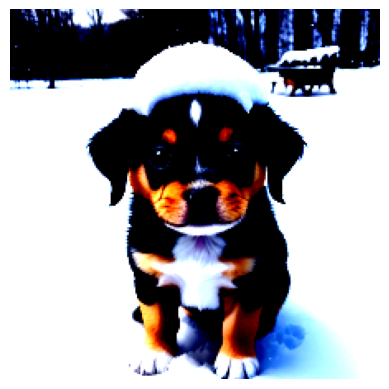

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# 准备图像以进行可视化
img = processed_image.squeeze(0)
img = img.permute(*torch.arange(img.ndim - 1, -1, -1))
img = np.einsum("ijk->jik", img)
# 可视化预处理后的图像
plt.imshow(img)
plt.axis("off")

预处理后的图像如图9-13所示。

<div align="center">
    <img src="./picture/9-13.jpg"/>
    <p>图9-13：CLIP预处理后的输入图像</p>
</div>

要将预处理后的图像转换为嵌入向量，我们可以像先前一样调用模型，并查看其返回结果的形状：

In [36]:
outputs = model.get_image_features(processed_image)

image_embedding = outputs.pooler_output
print(image_embedding.shape)

torch.Size([1, 512])


我们得到如下形状：

torch.Size([1, 512])

需要特别注意的是，生成的图像嵌入的形状与文本嵌入完全一致。这一特性至关重要，它使得我们能够比较两者的嵌入向量，进而判断其相似性。

为衡量两者的相似程度，我们首先需要对嵌入向量进行归一化处理，随后通过计算点积来获得相似度分数：

In [37]:
# 对嵌入向量进化归一化处理
text_embedding /= text_embedding.norm(dim=-1, keepdim=True)
image_embedding /= image_embedding.norm(dim=-1, keepdim=True)
# 计算它们的相似度
text_embedding = text_embedding.detach().cpu().numpy()
image_embedding = image_embedding.detach().cpu().numpy()
score = np.dot(text_embedding, image_embedding.T)
score

array([[0.3314964]], dtype=float32)

由此得出以下分数：

array([[0.3314964]], dtype=float32)

我们得到了约0.33的相似度分数，但由于我们并不清楚模型判定相似度高低的依据，这一分数仍难以准确解读。为此，我们增加更多图像与对应描述文本，对示例进行扩展，如图9-14所示。

<div align="center">
    <img src="./picture/9-14.jpg">
    <p>图9-14：三张图像与三段描述文本构成的相似度矩阵</p>
</div>

考虑这段文本与其他图像之间的相似度分数普遍偏低，0.33这一数值确实相当可观。

#### 使用sentence-transformers加载CLIP

sentence-transformers库已实现若干基于CLIP的模型，进一步简化了创建嵌入向量的过程：

In [48]:
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
puppy_image = Image.open(urlopen(puppy_path)).convert("RGB")
cat_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/cat.png"
cat_image = Image.open(urlopen(cat_path)).convert("RGB")
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"
car_image = Image.open(urlopen(car_path)).convert("RGB")
images = [puppy_image, cat_image, car_image]
captions = [
    "A puppy playing in the snow",
    "A pixelated image of a cute cat",
    "A supercar on the road with the sunset in the background"
]


In [49]:
from sentence_transformers import SentenceTransformer, util
# 加载兼容SBERT的CLIP模型
model = SentenceTransformer("clip-ViT-B-32")
# 对图像进行编码
image_embeddings = model.encode(images)
# 对描述文本进行编码
text_embeddings = model.encode(captions)
# 计算余弦相似度
sim_matrix = util.cos_sim(
    image_embeddings, text_embeddings
)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1903.74it/s]


In [50]:
print(sim_matrix.shape)
print(sim_matrix)


torch.Size([3, 3])
tensor([[0.3315, 0.1863, 0.1084],
        [0.1488, 0.3463, 0.0947],
        [0.0762, 0.1260, 0.3098]])


## 9.3 让文本生成模型具备多模态能力

传统意义上的文本生成模型，正如其名，是专精于文本表示解析的智能系统，这完全符合我们对这类模型的预期。以Llama2和ChatGPT为代表的先进模型，在文本信息推理与自然语言交互方面展现出卓越能力。

然而，受限于训练数据的模态特性，这类模型仅能处理文本信息。正如前文探讨的多模态嵌入模型所示，视觉能力的引入能显著扩展模型的功能边界。

对于文本生成模型而言，我们期望其能理解并推理输入的视觉信息。例如，当输入比萨的图片时，模型应能辨识其食材构成；面对埃菲尔铁塔的照片，模型需准确回答其建造年代与地理位置。图9-15直观展示了这种跨模态对话能力。

<div align="center">
    <img src="./picture/9-15.jpg">
    <p>图9-15：具备图像推理能力的多模态文本生成模型(BLIP-2)应用实例</p>
</div>

为架设跨模态的沟通桥梁，研究者致力于为现有模型注入多模态理解能力。一种实现方法是BLIP-2技术，采用创新的模块化设计，为传统语言模型赋予视觉认知能力。

### 9.3.1 BLIP-2：跨越模态鸿沟

从零构建多模态语言模型需耗费海量计算资源与多模态数据集。这种需要数十亿级图像、文本及图文配对数据的训练方式，实现难度可想而知。

BLIP-2的突破在于，通过构建名为查询式 Transformer(Querying Transformer，Q-Former)的智能桥梁，巧妙连接预训练视觉编码器与预训练LLM，而非重新构建整个系统架构。这种设计既保留了已有模型的优势，又实现了跨模态的信息传递。

该技术方案的精妙之处在于，仅需训练Q-Former模块，而无须从零训练视觉编码器与LLM。这种“借力使力”的智慧，使BLIP-2能最大化利用现有技术成果，其架构示意图见图9-16。

<div align="center">
    <img src="./picture/9-16.jpg">
    <p>图9-16：Q-Former作为连接视觉(ViT)与文本(LLM)的桥梁，是系统中唯一需要训练的核心组件</p>
</div>

为实现跨模态对接，Q-Former在架构设计上兼容双模态特性，包含两个共享注意力层的核心模块。

· 图像Transformer：与冻结的ViT交互，提取深层视觉特征。

· 文本Transformer：对接LLM，实现语义理解与生成。

该系统的训练流程分为两个阶段，针对两种模态分阶段优化。如图9-17所示，第一阶段使用图像-文本对（类似CLIP训练所用的图像和描述文本数据）进行联合表示学习，使模型同步掌握视觉与语言的对齐关系。

<div align="center">
    <img src="./picture/9-17.jpg">
    <p>图9-17：步骤1通过表示学习同步构建视觉与语言的联合表示空间，步骤2将这些表示转化为软视觉提示词并输入LLM</p>
</div>

图像首先被输入至冻结的ViT进行视觉特征提取。这些视觉嵌入随后作为Q-Former模块中ViT的输入，同时对应的描述文本则被输入至Q-Former的文本Transformer模块进行处理。

Q-Former通过这些输入接受训练，以完成三个目标任务。

图像-文本对比学习

该任务旨在对齐图像与文本的嵌入空间，通过最大化正例对的相似度实现跨模态关联。

图像-文本匹配

作为二分类任务，其目标是判断给定的图像-文本对是否构成正例（语义匹配）或负例（语义不匹配）​。

基于图像的文本生成

训练模型根据视觉特征生成与输入图像内容相关的文本描述。

针对这三项目标进行联合优化，可有效提升从冻结ViT中提取的视觉表示的质量，其本质是通过文本信息对冻结ViT的嵌入空间进行语义注入，使其适配LLM的输入需求。

BLIP-2的步骤1具体如图9-18所示。

<div align="center">
    <img src="./picture/9-18.jpg">
    <p>图9-18：步骤1中冻结的ViT输出与对应描述文本共同参与训练，通过三类对比任务学习视觉-文本联合表示</p>
</div>

在步骤2中，经步骤1训练得到的可学习嵌入已具备与文本语义空间对齐的视觉信息。这些嵌入向量通过投影层输入LLM，本质上充当软视觉提示词，使LLM的生成过程受Q-Former提取的视觉表示调控

特别地，系统通过全连接线性层对嵌入向量进行维度投影，确保其与LLM的输入维度兼容。这一视觉到语言的转换过程如图9-19所示。

<div align="center">
    <img src="./picture/9-19.jpg">
    <p>图9-19：步骤2中Q-Former学习到的嵌入向量经投影层输入预训练LLM，投影后的嵌入向量作为条件化生成的软视觉提示词</p>
</div>

当我们将这些步骤有机结合时，Q-Former便能在同一维度空间中学习视觉与文本表示，作为LLM的软提示词。这使得LLM能够以类似于接收上下文提示词的方式，自然地融合图像信息。BLIP-2的完整实现流程见图9-20。

<div align="center">
    <img src="./picture/9-20.jpg">
    <p>图9-20：BLIP-2的完整实现流程</p>
</div>

自BLIP-2问世以来，涌现出多个具有类似架构的视觉LLM，例如LLaVA，将文本LLM扩展为多模态的框架，以及基于Mistral 7B构建的高效视觉LLM Idefics2。尽管这些模型架构存在差异，但都采用预训练的类CLIP视觉编码器与文本LLM进行特征对接，其核心目标是将输入图像的视觉特征映射至语言嵌入空间，作为LLM的输入表示。这种思路与Q-Former殊途同归，均致力于弥合视觉模态与语言模态的语义鸿沟

### 9.3.2 多模态输入预处理

在深入探讨BLIP-2的构建原理后，我们发现这类模型具备丰富的应用场景，从图像描述生成、视觉问答，到复杂的提示工程任务均能胜任。

在具体实践前，让我们先完成模型加载并探索其使用方法：

In [ ]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch
# 加载处理器和主模型
blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16
)
# 将模型发送到GPU以加速推理
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\models--Salesforce--blip2-opt-2.7b. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

通过model.vision_model和model.language_model这两个属性，我们可以查看BLIP-2模型加载时具体采用了哪种ViT和生成模型。

我们首先加载构成完整处理流程的两个核心组件：处理器和模型。处理器类似于语言模型中的分词器，其功能是将非结构化输入（例如图像和文本）转换为模型所需的规范化表示形式。

图像预处理

我们先了解处理器对图像的处理流程。这里我们以一张宽幅图像作为示例：

In [ ]:
# 加载跑车图像
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"
image = Image.open(urlopen(car_path)).convert("RGB")
image

该图像尺寸为520像素×492像素，属于相对少见的比例。我们可通过以下步骤观察处理器的运作机制：

In [ ]:
# 预处理图像
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
inputs["pixel_values"].shape

In [40]:
由此我们可以得出以下形状：

SyntaxError: invalid character '：' (U+FF1A) (3857192531.py, line 1)

最终得到的图像尺寸为224像素×224像素，这比原始输入尺寸缩小了许多。这意味着所有不同比例的原始图像都将被统一转换为正方形。因此需特别注意，当输入特别宽或特别高的图像时，可能会因尺寸调整而导致画面失真。

文本预处理

接下来我们深入解析处理器的文本处理机制。首先需要调用文本分词的专用工具——分词器：blip_processor.tokenizer

经过处理，我们得到以下输出：

In [ ]:
GPT2TokenizerFast(name_or_path='Salesforce/blip2-opt-2.7b', vocab_size=50265, model_max_length=1000000000000000019884624838656, is_fast=True, pad- ding_side='right', truncation_side='right', special_tokens={'bos_token': '</ s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=True), added_tokens_decoder={
1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}

此处的BLIP-2模型采用了GPT2Tokenizer。正如我们在第2章中所讨论的，不同的分词器处理输入文本的方式可能存在显著差异。

为深入理解GPT2Tokenizer的工作原理，我们可以通过一个短句进行演示。首先将句子转换为词元ID序列，再将其转换回词元：

In [ ]:
# 预处理文本
text = "Her vocalization was remarkably melodic"
token_ids = blip_processor(image, text=text, return_tensors="pt")
token_ids = token_ids.to(device, torch.float16)["input_ids"][0]
# 将输入ID转换回词元
tokens = blip_processor.tokenizer.convert_ids_to_tokens(token_ids)
tokens

这将输出以下词元：

['</s>', 'Her', 'Ġvocal', 'ization', 'Ġwas', 'Ġremarkably', 'Ġmel', 'odic']

某些词元以特殊符号Ġ开头，这实际上代表空格。模型内部函数会将某些Unicode码位的字符值增加256，以便使其变为可打印字符，具体而言，空格字符（码位32）经过转换后就会呈现为Ġ符号（码位288）​。

为便于直观理解，我们在展示时将其转换为下划线

In [ ]:
# 将空格词元替换为下划线
tokens = [token.replace("Ġ", "_") for token in tokens]
tokens

我们得到更美观的输出：

['</s>', 'Her', '_vocal', 'ization', '_was', '_remarkably', '_mel', 'odic']

在上述输出中，下划线表示词的起始位置。通过这种方式，由多个词元组成的词便能够被有效识别。

### 9.3.3 用例1：图像描述

BLIP-2等模型最直观的应用就是为数据集中的图像生成描述文本。这类需求广泛存在于多个场景：服装电商可能需要为商品图自动生成卖点描述，摄影师则可能需要在短时间内完成上千张婚礼照片的自动化标注。

图像描述生成流程严格遵循标准处理范式。首先将图像转换为模型可识别的像素矩阵，这些视觉数据经过BLIP-2处理后会转换为软视觉提示词，供LLM解析并生成恰当的图像描述。

以跑车的图像为例，我们通过图像处理器将其转换为符合模型输入要求的像素矩阵：

In [ ]:
# 加载一张AI生成的跑车图像
image = Image.open(urlopen(car_path)).convert("RGB")
# 将图像转换为输入并进行预处理
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
image

下一步是使用BLIP-2模型将图像转换为词元ID。随后，我们可将这些词元ID进一步转换为对应的文本描述，即通过模型生成的图像语义表示：

In [41]:
# 为图像生成将被传递给解码器(LLM)的词元ID
generated_ids = model.generate(**inputs, max_new_tokens=20)
# 从词元ID生成文本
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

AttributeError: 'CLIPModel' object has no attribute 'generate'

generated_text所包含的图像描述为：

an orange supercar driving on the road at sunset

这堪称对该图像的完美诠释！

在探讨更复杂的应用场景之前，图像描述任务为我们提供了一个绝佳的模型认知窗口。读者可自行尝试上传不同图像，观察模型在哪些情况下表现优异，哪些情况下存在识别局限。需要特别指出的是，某些专业领域的图像（例如特定卡通角色或虚构创作）可能无法被准确描述，这是因为模型主要是基于公开数据集进行训练的。

最后，我们来看一个有趣的示例，来自罗夏墨迹测验(Rorschach Test)的一张图像（如图9-21所示）​。该测验源自一项古老的心理实验，旨在通过受试者对墨迹图像的感知解读其性格特征。尽管这种通过视觉联想进行心理评估的方法颇具主观色彩，但正是这种开放性使其展现出独特的魅力。

<div align="center">
    <img src="./picture/9-21.jpg"/>
    <p>图9-21：罗夏墨迹测验图像。你从中辨识出了哪些意象？</p>
</div>

现在，让我们以图9-21中的测验图像作为输入示例：

In [ ]:
# 加载测验图像
url = "https://upload.wikimedia.org/wikipedia/commons/7/70/Rorschach_blot_01.jpg"
image = Image.open(urlopen(url)).convert("RGB")
# 生成描述
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

与之前相同，当我们查看generated_text变量时，就能看到模型生成的描述文本：

a black and white ink drawing of a bat

你应该完全能够理解模型为何会这样描述这张图像（​“一张画着蝙蝠的黑白墨水画”​）​。既然这是一场测验，你认为这个回答反映出模型的哪些特性？

### 9.3.4 用例2：基于聊天的多模态提示词

基于图像描述这一重要任务，我们仍能够进一步拓展其应用场景。在前述示例中，我们展示了如何将一种模态（图像）转换为另一种模态（描述文本）​。

相较于遵循这种线性转换模式，我们可以尝试同时呈现两种模态——这种方法被称为视觉问答(visual questionanswering，VQA)。在此特定用例中，我们为模型提供一张图像及与之相关的问题，要求其进行解答。此时模型需要同步处理视觉信息与文本问题。

为演示这一过程，让我们从一张汽车图像开始，要求BLIP-2进行图像描述。首先需要按照先前多次操作的方式对图像进行预处理：

In [ ]:
# 加载一张AI生成的跑车图像
image = Image.open(urlopen(car_path)).convert("RGB")

若要进行视觉问答任务，我们不仅需要向BLIP-2提供图像，还需输入相应的提示词。若缺少提示词，模型将如之前所述，仅生成图像描述。接下来，我们将引导模型对当前处理的图像进行描述：

In [ ]:
# 视觉问答
prompt = "Question: Write down what you see in this picture. Answer:"
# 同时处理图像和提示词
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)
# 生成文本
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

我们得到如下输出：

A sports car driving on the road at sunset

模型准确描述了这张图像的内容。不过这个例子较为基础，因为我们的提问本质上是在要求模型生成描述文本。我们还可以以对话形式追问。

为此，我们可以将之前的对话记录（包括模型对问题的回答）提供给模型，再提出后续问题：

In [ ]:
# 类聊天式提示词
prompt = "Question: Write down what you see in this picture. Answer: A sports
car driving on the road at sunset. Question: What would it cost me to drive
that car? Answer:"
# 生成输出
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

我们得到如下输出：

$1,000,000

100万美元这个具体的数令人印象深刻！这展现了BLIP-2更趋近于聊天对话的特性，使我们能够展开妙趣横生的交流。

最后，我们可以借助ipywidgets构建交互式聊天机器人，让整个流程更加顺畅。ipywidgets作为Jupyter Notebook的扩展模块，支持创建交互式按钮、文本输入框等交互元素：

In [ ]:
from IPython.display import HTML, display
import ipywidgets as widgets
def text_eventhandler(*args):
  question = args[0]["new"]
  if question:
    args[0]["owner"].value = ""
    # 创建提示词
    if not memory:
      prompt = " Question: " + question + " Answer:"
    else:
      template = "Question: {} Answer: {}."
      prompt = " ".join(
          [
              template.format(memory[i][0], memory[i][1])
              for i in range(len(memory))
          ]
      ) + " Question: " + question + " Answer:"
    # 生成文本
    inputs = blip_processor(image, text=prompt, return_tensors="pt")
    inputs = inputs.to(device, torch.float16)
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = blip_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )
    generated_text = generated_text[0].strip().split("Question")[0]
    # 更新记忆
    memory.append((question, generated_text))
    # 分配到输出
    output.append_display_data(HTML("<b>USER:</b> " + question))
    output.append_display_data(HTML("<b>BLIP-2:</b> " + generated_text))
    output.append_display_data(HTML("<br>"))
# 准备组件
in_text = widgets.Text()
in_text.continuous_update = False
in_text.observe(text_eventhandler, "value")
output = widgets.Output()
memory = []
# 显示聊天框
display(
    widgets.VBox(
        children=[output, in_text],
        layout=widgets.Layout(display="inline-flex", flex_flow="columnreverse"),
    )
)

通过延续当前对话和持续提问能力，我们实际上构建了一个具备图像理解能力的智能对话系统！

## 9.4 小结

本章系统探讨了连接文本与视觉表示的多种技术路径，揭示了LLM实现多模态能力的核心机制。首先解析了ViT的架构创新，重点阐述了图像编码器通过分块嵌入策略实现的多尺度图像表示能力。这种技术突破使模型能够有效捕捉从局部细节到全局语义的视觉信息。

在视觉-文本联合表示方面，我们深入剖析了CLIP模型的对比学习范式。该模型通过在共享嵌入空间中对齐图文特征，成功实现了零样本分类、跨模态检索等突破性应用。特别值得关注的是OpenCLIP开源实现，为多模态嵌入任务提供了灵活高效的技术方案。

针对多模态生成模型，本章着重解析了BLIP-2的创新架构，其核心创新在于将视觉特征动态投影至语言模型的语义空间，实现了视觉信息与文本生成的深度融合。这种架构不仅支持精准的图像描述生成，更开创了多模态对话交互的新范式。本章通过多个应用场景的展示，有力印证了多模态LLM在智能搜索、辅助创作等领域的变革性潜力。

本书第三部分将聚焦模型训练与优化技术。第10章将深入探讨文本嵌入模型的构建与微调方法，这是支撑语言模型应用的核心技术栈。后续章节将系统展开语言模型训练范式的全景解析，为读者构建完整的知识体系。